# Examen 2 
- Paola Figueroa
- 13/Mayo/2026

# **Pregunta 11**

- Ejercicio Práctico 1: Análisis de estrategias de opciones con datos reales

- Usando yfinance, descarga la cadena de opciones vigente de un activo de tu elección con opciones líquidas.
- Selecciona los contratos necesarios para construir dos de las siguientes estrategias (cada estudiante elige cuáles):
    - Long straddle
    - Bull call spread
    - Bear put spread
    - Iron condor
    - Protective put
- Para cada estrategia: grafica el diagrama de payoff al vencimiento, e indica claramente el breakeven, la ganancia máxima y la pérdida máxima.
- Reporta las Griegas individuales de cada contrato usado (Delta, Gamma, Theta, Vega) tomándolas de la cadena de opciones o calculándolas con Black-Scholes. Calcula las Griegas netas del portafolio resultante de cada estrategia.
- En markdown: explica en qué condición de mercado (dirección esperada y nivel de volatilidad) tiene sentido cada estrategia construida. Vincula explícitamente tu respuesta con el signo e interpretación de al menos dos Griegas netas calculadas.
- Entregable: link a notebook en Colab o GitHub (.py con PDF/markdown adjunto). Código limpio, comentado y con gráficas claras.

## **Librerías**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import yfinance as yf
from datetime import datetime

## **Funciones de griegas y payoff**

In [10]:
#  FUNCIONES BASE (Griegas y Payoff) 

def greeks(S, K, r, T, sigma, option='call'):
    """Calcula las griegas usando el modelo Black-Scholes."""
    if T <= 0 or sigma <= 0:
        return {k: 0 for k in ['delta','gamma','vega','theta','rho']}
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
    vega  = S*norm.pdf(d1)*np.sqrt(T) / 100
    
    if option == 'call':
        delta = norm.cdf(d1)
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365
        rho   =  K*T*np.exp(-r*T)*norm.cdf(d2) / 100
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)) / 365
        rho   = -K*T*np.exp(-r*T)*norm.cdf(-d2) / 100
        
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta, 'rho': rho}

def calcular_pnl_estrategia(S_range, legs):
    """Calcula el P&L neto de una estrategia."""
    total_pnl = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        total_pnl += leg['posicion'] * (payoff - leg['prima'])
    return total_pnl


## **Precios**

In [3]:
ticker = yf.Ticker("NVDA")
S0 = ticker.history(period="1d")['Close'].iloc[-1]
r = 0.045
chosen_expiry = ticker.options[1]
opt = ticker.option_chain(chosen_expiry)
T = (datetime.strptime(chosen_expiry, '%Y-%m-%d') - datetime.now()).days / 365

## **Estrategias**

In [ ]:
 # Selección de contratos
c_buy = opt.calls.iloc[(opt.calls['strike'] - S0).abs().argsort()[:1]].iloc[0]
c_sell = opt.calls.iloc[(opt.calls['strike'] - (S0 * 1.05)).abs().argsort()[:1]].iloc[0]
p_buy = opt.puts.iloc[(opt.puts['strike'] - S0).abs().argsort()[:1]].iloc[0]
#  CÁLCULO DE GRIEGAS INDIVIDUALES Y NETAS 
g_cb = greeks(S0, c_buy['strike'], r, T, c_buy['impliedVolatility'], 'call')
g_cs = greeks(S0, c_sell['strike'], r, T, c_sell['impliedVolatility'], 'call')
g_pb = greeks(S0, p_buy['strike'], r, T, p_buy['impliedVolatility'], 'put')

g_net_bull = {k: g_cb[k] - g_cs[k] for k in g_cb}
g_net_strad = {k: g_cb[k] + g_pb[k] for k in g_cb}

# Tabla de Griegas
df_reporte = pd.DataFrame({
    "Contrato": ["Long Call (K1)", "Short Call (K2)", "Long Put (K_atm)", "NETO BULL SPREAD", "NETO STRADDLE"],
    "Strike": [c_buy['strike'], c_sell['strike'], p_buy['strike'], "-", "-"],
    "Delta": [g_cb['delta'], -g_cs['delta'], g_pb['delta'], g_net_bull['delta'], g_net_strad['delta']],
    "Gamma": [g_cb['gamma'], -g_cs['gamma'], g_pb['gamma'], g_net_bull['gamma'], g_net_strad['gamma']],
    "Vega": [g_cb['vega'], -g_cs['vega'], g_pb['vega'], g_net_bull['vega'], g_net_strad['vega']],
    "Theta": [g_cb['theta'], -g_cs['theta'], g_pb['theta'], g_net_bull['theta'], g_net_strad['theta']]
})

print(f"\n--- REPORTE DE GRIEGAS: {ticker} @ {S0:.2f} ---")
print(df_reporte.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))


--- REPORTE DE GRIEGAS: yfinance.Ticker object <NVDA> @ 225.83 ---
        Contrato   Strike   Delta   Gamma    Vega   Theta
  Long Call (K1) 225.0000  0.5456  0.0386  0.0937 -0.5236
 Short Call (K2) 235.0000 -0.2056 -0.0271 -0.0673  0.3793
Long Put (K_atm) 225.0000 -0.4533  0.0401  0.0937 -0.4768
NETO BULL SPREAD        -  0.3400  0.0115  0.0264 -0.1443
   NETO STRADDLE        -  0.0923  0.0786  0.1874 -1.0004


## **Visualizaciones**

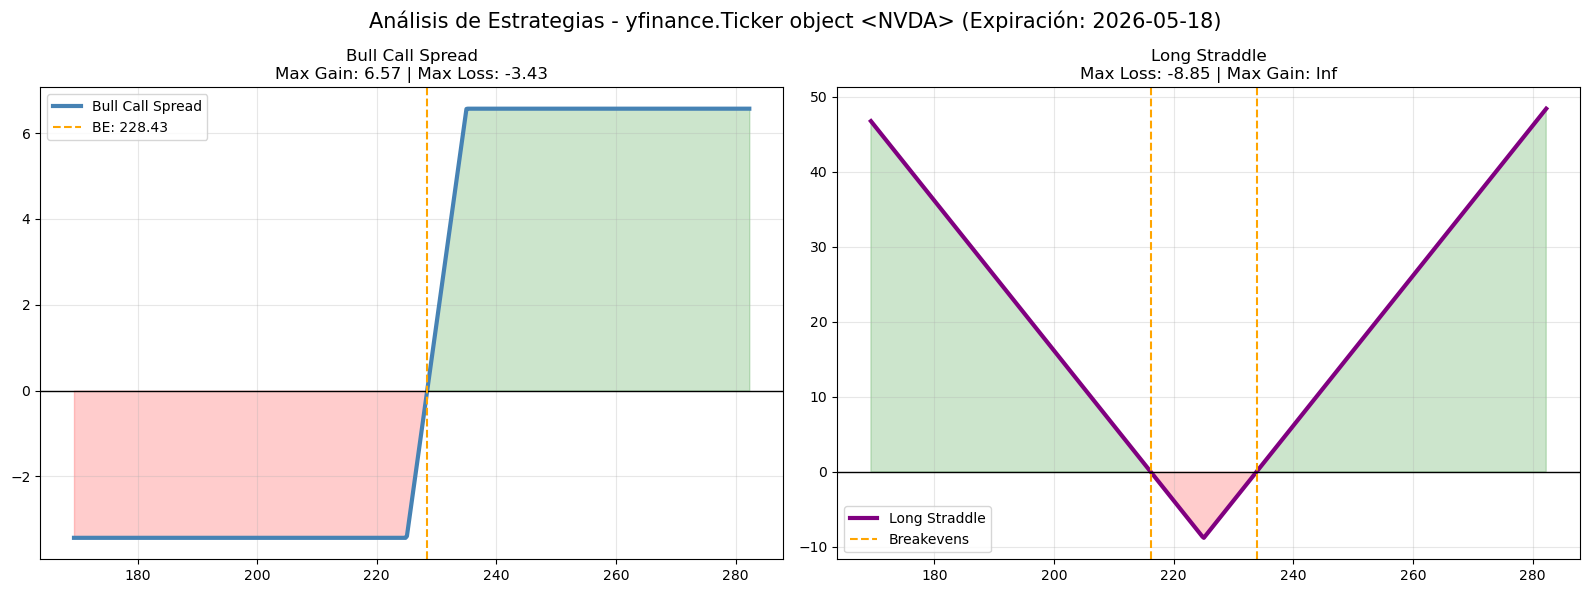

In [5]:
S_plot = np.linspace(S0 * 0.75, S0 * 1.25, 500)

# Datos Bull Spread
costo_bull = c_buy['lastPrice'] - c_sell['lastPrice']
pnl_bull = (np.maximum(S_plot - c_buy['strike'], 0) - c_buy['lastPrice']) - \
           (np.maximum(S_plot - c_sell['strike'], 0) - c_sell['lastPrice'])

# Datos Straddle
costo_strad = c_buy['lastPrice'] + p_buy['lastPrice']
pnl_strad = (np.maximum(S_plot - c_buy['strike'], 0) - c_buy['lastPrice']) + \
            (np.maximum(p_buy['strike'] - S_plot, 0) - p_buy['lastPrice'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Visualización Bull Spread
ax1.plot(S_plot, pnl_bull, color='steelblue', lw=3, label='Bull Call Spread')
ax1.fill_between(S_plot, pnl_bull, 0, where=(pnl_bull > 0), color='green', alpha=0.2)
ax1.fill_between(S_plot, pnl_bull, 0, where=(pnl_bull < 0), color='red', alpha=0.2)
ax1.axhline(0, color='black', lw=1)
ax1.axvline(c_buy['strike'] + costo_bull, color='orange', ls='--', label=f"BE: {c_buy['strike']+costo_bull:.2f}")
ax1.set_title(f"Bull Call Spread\nMax Gain: {(c_sell['strike']-c_buy['strike'])-costo_bull:.2f} | Max Loss: {-costo_bull:.2f}")
ax1.legend()
ax1.grid(alpha=0.3)

# Visualización Straddle
ax2.plot(S_plot, pnl_strad, color='purple', lw=3, label='Long Straddle')
ax2.fill_between(S_plot, pnl_strad, 0, where=(pnl_strad > 0), color='green', alpha=0.2)
ax2.fill_between(S_plot, pnl_strad, 0, where=(pnl_strad < 0), color='red', alpha=0.2)
ax2.axhline(0, color='black', lw=1)
ax2.axvline(c_buy['strike'] + costo_strad, color='orange', ls='--')
ax2.axvline(c_buy['strike'] - costo_strad, color='orange', ls='--', label="Breakevens")
ax2.set_title(f"Long Straddle\nMax Loss: {-costo_strad:.2f} | Max Gain: Inf")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(f"Análisis de Estrategias - {ticker} (Expiración: {chosen_expiry})", fontsize=15)
plt.tight_layout()
plt.show()

La estrategia Bull Call Spread es ideal para un escenario de optimismo moderado, donde se espera que el precio de NVDA suba pero sin necesariamente presentar un movimiento explosivo. Al observar las Griegas netas, el Delta positivo (0.3400) confirma este sesgo alcista, indicando que la posición ganará valor a medida que la acción suba, aunque de forma más contenida que una compra directa. Por otro lado, el Theta neto negativo (-0.1443), al ser un valor relativamente bajo, nos muestra que aunque el paso del tiempo juega en contra de la posición, el efecto es moderado gracias a la opción vendida que financia la estrategia. Como se ve en el gráfico de la izquierda, la ganancia está limitada a partir de los $235, lo que la hace eficiente en mercados de baja volatilidad o subidas graduales.

Por el contrario, el Long Straddle es una apuesta pura a la volatilidad, recomendada cuando se prevé un movimiento brusco en el precio pero existe total incertidumbre sobre su dirección, como ocurre típicamente antes de un reporte de beneficios. En este caso, el Vega neto positivo (0.1874) es fundamental, ya que implica que un aumento en el miedo o la incertidumbre del mercado (volatilidad implícita) inflará el precio de nuestras opciones y beneficiará la estrategia incluso antes de que el precio se mueva. Además, el Gamma neto positivo (0.0786) actúa como un acelerador: a medida que NVDA se aleja del precio de ejercicio de $225, el Delta de la posición se ajusta automáticamente para capturar ganancias más rápidas en la dirección de la tendencia. Esto se refleja claramente en la curva en forma de "V" del gráfico derecho, donde cualquier movimiento fuerte hacia los extremos genera beneficios significativos.

# **Pregunta 12**

## **Parámetros y justificación**

In [6]:
S0    = 180.0   # Precio Spot: Valor representativo de un activo volátil como TSLA.
K     = 190.0   # Strike: OTM para observar el impacto de la probabilidad de ejercicio.
T     = 0.5     # Plazo: 6 meses (126 días hábiles), horizonte estándar para opciones semestrales.
r     = 0.0525  # Tasa: Alineada con el rendimiento de los bonos del tesoro (T-Bills) a 6 meses.
sigma = 0.48    # Volatilidad: Desviación estándar anualizada para capturar movimientos agresivos.
B     = 240.0   # Barrera: Nivel de "extinción" (Up-and-Out) situado un 33% arriba del spot.
N_SIM = 50_000  # Número de trayectorias solicitado.
N_PASOS = 126   # Pasos diarios.
dt = T / N_PASOS
df = np.exp(-r * T)
np.random.seed(42)

## **Trayectorias**

In [7]:
Z = np.random.standard_normal((N_PASOS, N_SIM))
log_retornos = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
log_S = np.cumsum(np.vstack([np.full(N_SIM, np.log(S0)), log_retornos]), axis=0)
trayectorias = np.exp(log_S)

## **Payoff y Precios**

In [8]:
ST = trayectorias[-1, :] # Precios finales

p_call_eur = np.maximum(ST - K, 0)
p_put_eur  = np.maximum(K - ST, 0)
p_asiatica = np.maximum(np.mean(trayectorias, axis=0) - K, 0)
# Up-and-out: Si toca B, el payoff se vuelve cero en toda la trayectoria.
toco_barrera = np.any(trayectorias >= B, axis=0)
p_barrera = np.where(toco_barrera, 0, p_call_eur)
resultados = {
    "Opción": ["Call Europea", "Put Europea", "Asiática (Call)", "Barrera U&O (Call)"],
    "Precio MC": [df * np.mean(p_call_eur), df * np.mean(p_put_eur), 
                  df * np.mean(p_asiatica), df * np.mean(p_barrera)]
}

df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))

            Opción  Precio MC
      Call Europea  21.951636
       Put Europea  27.244785
   Asiática (Call)  10.698419
Barrera U&O (Call)   1.959795


## **Distribución de precios**

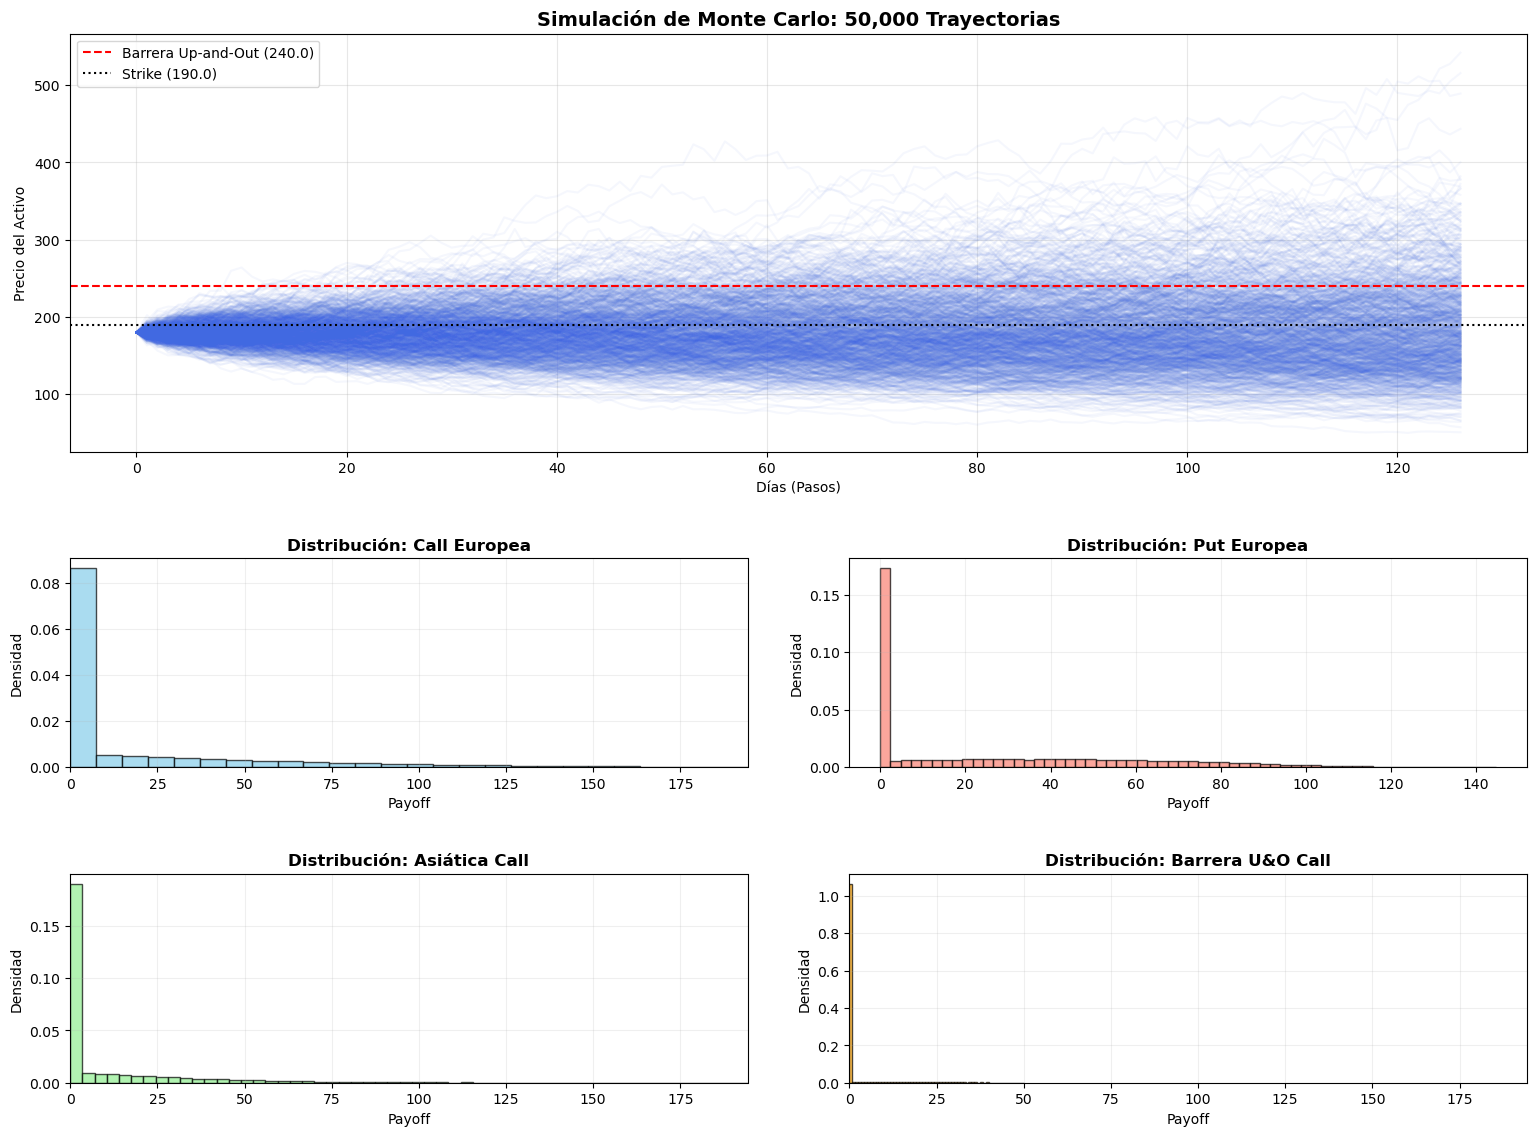

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 1, 1])

# Simulación de MonteCarlo
ax_main = fig.add_subplot(gs[0, :])
ax_main.plot(trayectorias[:, :1000], color='royalblue', alpha=0.05) 
ax_main.axhline(B, color='red', linestyle='--', label=f'Barrera Up-and-Out ({B})')
ax_main.axhline(K, color='black', linestyle=':', label=f'Strike ({K})')
ax_main.set_title(f"Simulación de Monte Carlo: {N_SIM:,} Trayectorias", fontsize=14, fontweight='bold')
ax_main.set_xlabel("Días (Pasos)")
ax_main.set_ylabel("Precio del Activo")
ax_main.legend(loc='upper left')
ax_main.grid(alpha=0.3)

# Payoffs
payoffs_list = [p_call_eur, p_put_eur, p_asiatica, p_barrera]
titulos_list = ["Call Europea", "Put Europea", "Asiática Call", "Barrera U&O Call"]
colores_list = ['skyblue', 'salmon', 'lightgreen', 'orange']
posiciones = [(1, 0), (1, 1), (2, 0), (2, 1)]

for i, (p_data, titulo, color) in enumerate(zip(payoffs_list, titulos_list, colores_list)):
    ax = fig.add_subplot(gs[posiciones[i][0], posiciones[i][1]])
    ax.hist(p_data, bins=60, color=color, edgecolor='black', alpha=0.7, density=True)
    ax.set_title(f"Distribución: {titulo}", fontweight='bold')
    ax.set_xlabel("Payoff")
    ax.set_ylabel("Densidad")
    
    # Ajuste de escala para comparar Calls (excepto en la Put)
    if i != 1:
        ax.set_xlim(0, np.percentile(p_call_eur, 99))
    ax.grid(alpha=0.2)

plt.tight_layout(pad=3.0)
plt.show()

La diferencia de precios radica en las restricciones que las opciones exóticas imponen al titular. Como se observa en la Asiática Call, el uso de un promedio aritmético en lugar del precio final suaviza la volatilidad; esto reduce la probabilidad de alcanzar pagos extremadamente altos, ya que los picos de precio al vencimiento se promedian con valores anteriores más bajos. En los histogramas esto se evidencia en una distribución de pagos más comprimida hacia la izquierda en comparación con la Call Europea, lo que justifica un costo significativamente menor al reducirse el valor esperado del contrato.
Por otro lado, la Opción de Barrera (Up-and-Out) es la más barata debido al riesgo de extinción. Al observar las trayectorias, muchas líneas azules cruzan la línea roja punteada (barrera de $240$); en ese instante, la opción muere y su valor se vuelve cero, sin importar qué tan alto termine el precio al final. Esta característica elimina del cálculo todas las trayectorias con mayores ganancias potenciales, dejando un histograma casi vacío en los niveles altos de payoff, lo que representa una pérdida de derechos para el inversor que se compensa con una prima mucho más baja.
Finalmente, la comparación con la Put Europea muestra que el precio no solo depende de la estructura del payoff, sino de la posición inicial respecto al strike. Al ser el precio actual ($180$) menor al strike ($190$), la Put tiene valor intrínseco desde el día uno, lo que eleva su precio por encima de las opciones de compra. En resumen, las exóticas son más económicas porque el comprador acepta límites (ya sea mediante el promedio de precios o el riesgo de cancelación por barrera) que protegen al emisor de escenarios de pagos masivos.